# Student ML Project: Spam Message Classification

## Project Idea
In this project, you will build a machine learning model that classifies text messages as:

- **ham**: normal message
- **spam**: unwanted promotional or scam message

This is a **text classification / NLP project**, not an image project.

## Student Objectives
By the end of this notebook, you should be able to:

1. Create and load a text dataset.
2. Explore text data.
3. Clean text messages.
4. Convert text into numerical features using **TF-IDF**.
5. Split data into training and testing sets.
6. Train different machine learning models.
7. Compare model accuracy.
8. Evaluate the best model using a confusion matrix and classification report.
9. Test the model using new custom messages.

---

## 1. Import Libraries

### TODO
Run the cell below to import the required libraries.


In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Text processing
import re
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Create the Text Dataset

The dataset contains short text messages and their labels.

### TODO
1. Run the cell to create the dataset.
2. Convert it into a DataFrame.
3. Display the first rows.


In [ ]:
df = pd.read_csv("/content/real_sms_spam_dataset_sample.csv")
df.head()

,label,label_num,message
0,ham,0,"Go until jurong point, crazy.. Available only ..."
1,ham,0,Ok lar... Joking wif u oni...
2,spam,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,0,U dun say so early hor... U c already then say...
4,ham,0,"Nah I don't think he goes to usf, he lives aro..."


## 3. Understand the Dataset

### TODO
Write code to answer these questions:

1. How many rows and columns are in the dataset?
2. What are the column names?
3. What are the data types?
4. How many spam and ham messages are there?
5. Are there missing values?
6. Are there duplicated messages?


In [ ]:
# TODO: Display the shape of the dataset
# 1. Display the shape of the dataset
df.shape

(193, 3)

In [ ]:
# TODO: Display column names
# 2. Display column names
df.columns

Index(['label', 'label_num', 'message'], dtype='object')

In [ ]:
# TODO: Display dataset information
# 3. Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      193 non-null    object
 1   label_num  193 non-null    int64 
 2   message    193 non-null    object
dtypes: int64(1), object(2)
memory usage: 4.7+ KB


In [ ]:
# TODO: Count spam and ham messages
# 4. Count spam and ham messages
df['label'].value_counts()

,count
label,
ham,166
spam,27


In [ ]:
# TODO: Check missing values
# 5. Check missing values
df.isnull().sum()

,0
label,0
label_num,0
message,0


In [ ]:
# TODO: Check duplicated rows
# 6. Check duplicated rows
df.duplicated().sum()

np.int64(0)

## 4. Text Length Analysis

Text length can sometimes help us understand patterns in spam and ham messages.

### TODO
1. Create a new column called `message_length`.
2. Calculate the number of characters in each message.
3. Compare message length between spam and ham.


In [ ]:
# TODO: Create message_length column
# 1. Create message_length column
df['message_length'] = df['message'].apply(len)

In [ ]:
# TODO: Show average message length for each label
# 2. Show average message length for each label
df.groupby('label')['message_length'].mean()

,message_length
label,
ham,49.373494
spam,84.666667


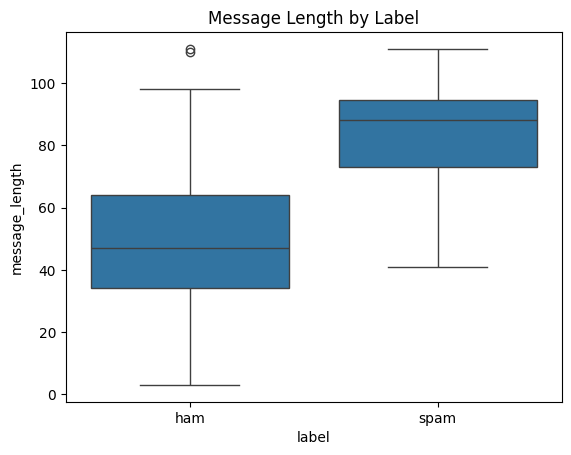

In [ ]:
# TODO: Plot message length by label
# 3. Plot message length by label
sns.boxplot(x='label', y='message_length', data=df)
plt.title('Message Length by Label')
plt.show()

## 5. Clean the Text

Text data usually contains uppercase letters, punctuation, numbers, and extra spaces.

We will create a function to clean text.

### TODO
The function should:
1. Convert text to lowercase.
2. Remove punctuation.
3. Remove numbers.
4. Remove extra spaces.


In [ ]:
# TODO: Create clean_text function
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
# TODO: Apply the clean_text function to the message column
df['clean_message'] = df['message'].apply(clean_text)

# Display the first few rows to verify the changes
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## 6. Exploratory Data Analysis

### TODO
Create visualizations to understand the dataset.

Required:
1. Bar chart showing the number of spam and ham messages.
2. Histogram of message length.
3. Show the most common words in spam messages.
4. Show the most common words in ham messages.


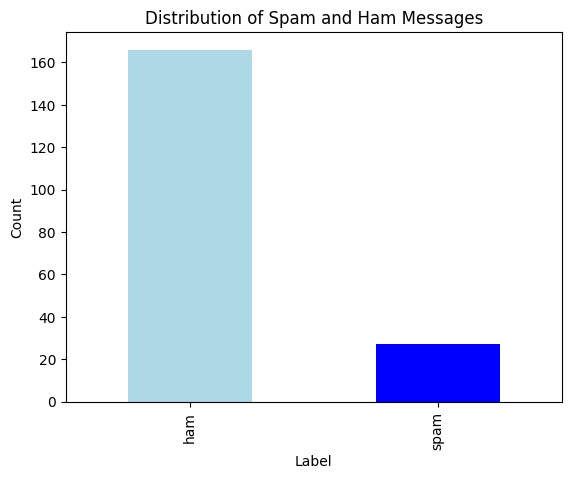

In [ ]:
# TODO: Create a bar chart for label distribution
# 1. Create a bar chart for label distribution
df['label'].value_counts().plot(kind='bar', color=['lightblue', 'blue'])
plt.title('Distribution of Spam and Ham Messages')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

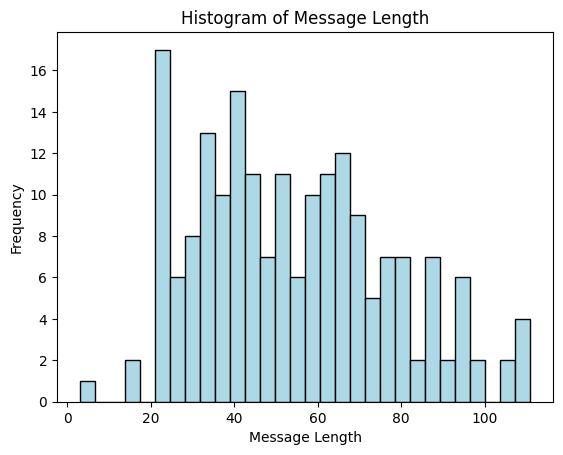

In [ ]:
# TODO: Create a histogram of message length
# 2. Create a histogram of message length
df['message_length'].plot(kind='hist', bins=30, color='lightblue', edgecolor='black')
plt.title('Histogram of Message Length')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Helper function to get common words

from collections import Counter

def get_common_words(text_series, top_n=10):
    all_words = " ".join(text_series).split()
    word_counts = Counter(all_words)
    return pd.DataFrame(word_counts.most_common(top_n), columns=["word", "count"])

In [ ]:
# TODO: Show most common words in spam messages
# 4. Show most common words in spam messages
spam_words_df = get_common_words(df[df['label'] == 'spam']['clean_message'])
spam_words_df

,word,count
0,to,22
1,your,15
2,you,13
3,a,10
4,call,10
5,now,9
6,cash,8
7,free,7
8,text,7
9,and,7


In [ ]:
# TODO: Show most common words in ham messages
# 5. Show most common words in ham messages
ham_words_df = get_common_words(df[df['label'] == 'ham']['clean_message'])
ham_words_df

,word,count
0,i,69
1,you,54
2,to,51
3,the,26
4,and,21
5,have,21
6,it,21
7,a,20
8,in,17
9,im,17


## 7. Prepare Data for Machine Learning

Machine learning models cannot understand raw text directly.

We need to convert text into numbers using **TF-IDF Vectorization**.

### TODO
1. Store cleaned messages in `X`.
2. Store labels in `y`.
3. Split the data into training and testing sets.
4. Use `test_size=0.2`.
5. Use `random_state=42`.
6. Use `stratify=y`.


In [ ]:
# TODO: Create X and y
# 1. Define X and y
X = df['clean_message']
y = df['label_num']

In [ ]:
# TODO: Split the data
# 2. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 8. Convert Text to Numbers Using TF-IDF

TF-IDF means **Term Frequency - Inverse Document Frequency**.

It gives higher importance to words that are useful for classification.

### TODO
1. Create a `TfidfVectorizer`.
2. Fit it on the training text only.
3. Transform the training and testing text.


In [ ]:
# TODO: Create and apply TF-IDF
# 1. Create and fit TF-IDF Vectorizer
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)

In [ ]:
# 2. Transform test data
X_test_tfidf = vectorizer.transform(X_test)

## 9. Train Different Machine Learning Models

You will compare several classification algorithms:

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Machine
4. Decision Tree
5. Random Forest

### TODO
Train each model and calculate accuracy.


In [ ]:
# TODO: Create a dictionary of models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [ ]:
# TODO: Train models and store accuracy scores
accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    predictions = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, predictions)
    accuracy_scores[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

Naive Bayes Accuracy: 0.8718
Logistic Regression Accuracy: 0.8462
Linear SVM Accuracy: 0.8974
Decision Tree Accuracy: 0.9231
Random Forest Accuracy: 0.8718


## 10. Compare Model Accuracy

### TODO
1. Convert model results into a DataFrame.
2. Sort models by accuracy.
3. Create a bar chart comparing accuracy.
4. Identify the best model.


In [ ]:
# TODO: Convert results to DataFrame
import pandas as pd
results_df = pd.DataFrame(list(accuracy_scores.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
results_df

,Model,Accuracy
3,Decision Tree,0.923077
2,Linear SVM,0.897436
0,Naive Bayes,0.871795
4,Random Forest,0.871795
1,Logistic Regression,0.846154


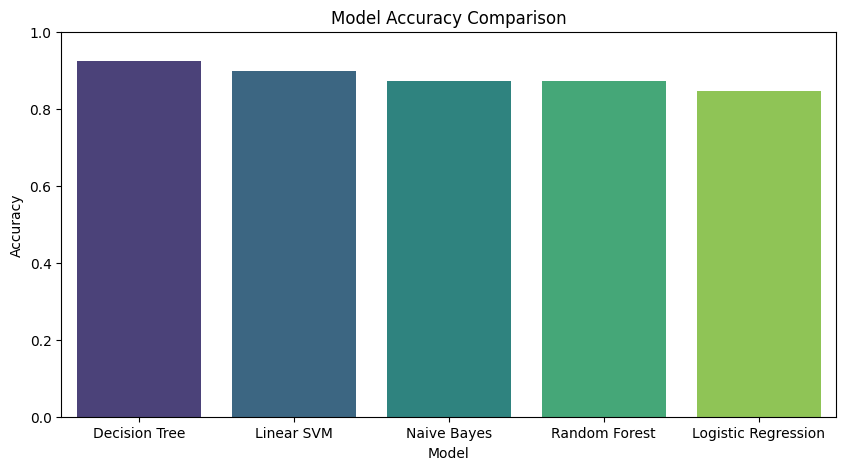

In [ ]:
# TODO: Plot model accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1.0)
plt.show()

## 11. Evaluate the Best Model

After comparing all models, choose the best one and evaluate it more deeply.

### TODO
1. Choose the best model.
2. Train it again.
3. Predict test messages.
4. Display the confusion matrix.
5. Display the classification report.


In [ ]:
# TODO: Choose the best model name based on your results
# Based on Section 10 results, 'Decision Tree' had the highest accuracy (0.9231)
best_model_name = "Decision Tree"
best_model = models[best_model_name]

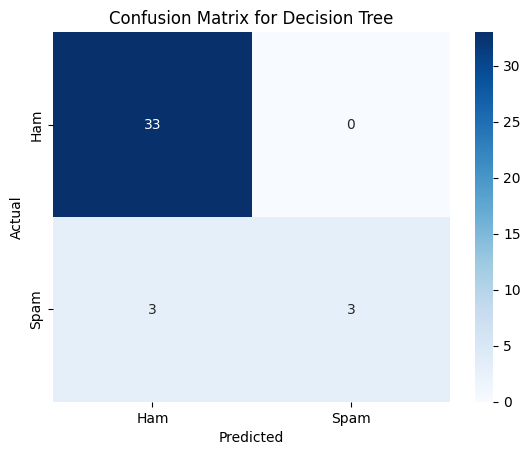

In [ ]:
# TODO: Display confusion matrix
best_pred = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, best_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# TODO: Display classification report
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        33
           1       1.00      0.50      0.67         6

    accuracy                           0.92        39
   macro avg       0.96      0.75      0.81        39
weighted avg       0.93      0.92      0.91        39



## 12. Test the Model With New Messages

Now try your model with new messages.

### TODO
1. Write new custom messages.
2. Clean the messages.
3. Transform them using the same TF-IDF vectorizer.
4. Predict whether each message is spam or ham.


In [ ]:
# TODO: Try your own messages
# 1. Write new custom messages
custom_messages = [
    "Hello friend, are we still meeting up for coffee later tonight?",
    "URGENT: Your mobile number has won £2,000,000 in our cash prize draw! Call 09061104282 to claim now."
]

# 2. Clean the messages
cleaned_messages = [clean_text(msg) for msg in custom_messages]

# 3. Transform them using the same TF-IDF vectorizer
custom_tfidf = vectorizer.transform(cleaned_messages)

# 4. Predict whether each message is spam or ham
custom_predictions = best_model.predict(custom_tfidf)

# Display the final prediction results
for msg, pred in zip(custom_messages, custom_predictions):
    label = "Spam" if pred == 1 else "Ham"
    print(f"Message: '{msg}' --> Predicted as: {label}")

Message: 'Hello friend, are we still meeting up for coffee later tonight?' --> Predicted as: Ham
Message: 'URGENT: Your mobile number has won £2,000,000 in our cash prize draw! Call 09061104282 to claim now.' --> Predicted as: Spam


## 13. Student Questions

Answer the following questions in Markdown cells:

1. What is the difference between spam and ham?
2. Why do we need to clean text before training?
3. What does TF-IDF do?
4. Which words are common in spam messages?
5. Which words are common in ham messages?
6. Which model achieved the highest accuracy?
7. What does the confusion matrix show?
8. How can we improve the model?


In [ ]:
# TODO: Write your answers in a Markdown cell below.

1. What is the difference between spam and ham?

Spam refers to unwanted or promotional messages, while ham refers to legitimate personal or business messages.

الرسائل المزعجة (سبام) هي الرسائل غير المرغوب فيها أو الإعلانية، والرسائل الطبيعية (هام) هي الرسائل الشخصية أو العملية الموثوقة.

2. Why do we need to clean text before training?

To remove noise like punctuation and symbols, allowing the model to focus only on important words.

لإزالة الضوضاء مثل الرموز وعلامات الترقيم، مما يساعد النموذج على التركيز على الكلمات المهمة فقط.

3. What does TF-IDF do?

It converts text into numbers by evaluating how important a word is to a document relative to the whole dataset.

يحول النصوص إلى أرقام عبر قياس مدى أهمية الكلمة في الرسالة مقارنة بباقي البيانات.

4. Which words are common in spam messages?

Promotional and financial words such as: free, cash, call, and now.

الكلمات الشائعة في الرسائل المزعجة هي الكلمات التسويقية والمالية مثل: free، cash، call، و now.

5. Which words are common in ham messages?

Everyday conversational words such as: i, you, to, and the.

الكلمات الشائعة في الرسائل الطبيعية هي كلمات المحادثات اليومية العادية مثل: i، you، to، و the.

6. Which model achieved the highest accuracy?

The Decision Tree model achieved the highest accuracy with 92.3%.

نموذج شجرة القرار (Decision Tree) حقق أعلى دقة بنسبة 92.3%.

7. What does the confusion matrix show?

It shows the exact counts of correct and incorrect predictions made by the model.

توضح مصفوفة الارتباك الأعداد الدقيقة للتوقعات الصحيحة والخاطئة التي قام بها النموذج.

8. How can we improve the model?

By gathering more data, fine-tuning model hyperparameters, or removing more common stop words during cleaning.

من خلال جمع بيانات أكثر، أو ضبط بارامترات النموذج بدقة أعلى، أو تصفية الكلمات الشائعة بشكل أفضل أثناء التنظيف.